In [16]:
# Student Name: Voris
# Student ID: 230646
import cv2
import numpy as np
import matplotlib.pyplot as plt
def validate_image(image):
    if image is None:
        raise ValueError("Invalid image input.")
    if not isinstance(image, np.ndarray):
        raise TypeError("Input must be a NumPy array.")
    return image


def to_float(image):
    return image.astype(np.float32) / 255.0


def to_uint8(image):
    image = np.clip(image * 255, 0, 255)
    return image.astype(np.uint8)

In [17]:
# Part 1 – Gamma Correction
# Challenge 1.1
def gamma_correction(image, gamma):
    validate_image(image)
    if gamma <= 0:
        raise ValueError("Gamma must be > 0")

    normalized = to_float(image)
    corrected = np.power(normalized, gamma)
    return to_uint8(corrected)

In [18]:
# Challenge 1.2 – Gamma Curve Analysis
def plot_gamma_curves():
    r = np.linspace(0, 1, 256)
    gamma_values = [0.3, 0.5, 1.0, 2.0, 3.0]

    plt.figure(figsize=(8, 6))
    for g in gamma_values:
        s = np.power(r, g)
        plt.plot(r, s, label=f'γ = {g}')

    plt.title("Gamma Curves Analysis")
    plt.xlabel("Input Intensity (r)")
    plt.ylabel("Output Intensity (s)")
    plt.legend()
    plt.grid(True)
    plt.show()

In [19]:
# Challenge 1.3 – Comparative Study
def comparative_gamma(image):
    gammas = [0.5, 1.0, 2.0]

    plt.figure(figsize=(12, 4))
    for i, g in enumerate(gammas):
        corrected = gamma_correction(image, g)
        plt.subplot(1, 3, i + 1)
        plt.imshow(corrected)
        plt.title(f'Gamma = {g}')
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [20]:
# Part 2 – Basic Intensity Transformations
# Challenge 2.1 – Image Negative
def image_negative(image):
    validate_image(image)
    negative = 255 - image
    return negative.astype(np.uint8)

In [21]:
# Challenge 2.2 – Intensity Range Mapping
def intensity_range_mapping(image, A, B):
    validate_image(image)

    if not (0 <= A <= 255 and 0 <= B <= 255):
        raise ValueError("A and B must be within [0,255]")
    if A > B:
        raise ValueError("A must be <= B")

    result = image.copy()

    mask = (image >= A) & (image <= B)
    result[mask] = 255

    return result

In [22]:
# Challenge 2.3 – Integrated Enhancement Pipeline
def enhancement_pipeline(image_path, gamma, A, B):
    image = cv2.imread(image_path)
    validate_image(image)

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    gamma_img = gamma_correction(image, gamma)
    enhanced = intensity_range_mapping(gamma_img, A, B)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(image)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(gamma_img)
    plt.title(f"Gamma = {gamma}")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(enhanced)
    plt.title(f"Intensity [{A},{B}] → White")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [23]:
# Final Task
def final_execution(image_path):
    image = cv2.imread(image_path)
    validate_image(image)

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plot_gamma_curves()

    gamma_img = gamma_correction(image, 2.0)
    negative_img = image_negative(image)
    mapped_img = intensity_range_mapping(image, 100, 180)

    plt.figure(figsize=(14, 8))

    titles = ["Original", "Gamma (2.0)", "Negative", "Range Mapping [100,180]"]
    images = [image, gamma_img, negative_img, mapped_img]

    for i in range(4):
        plt.subplot(2, 2, i + 1)
        plt.imshow(images[i])
        plt.title(titles[i])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

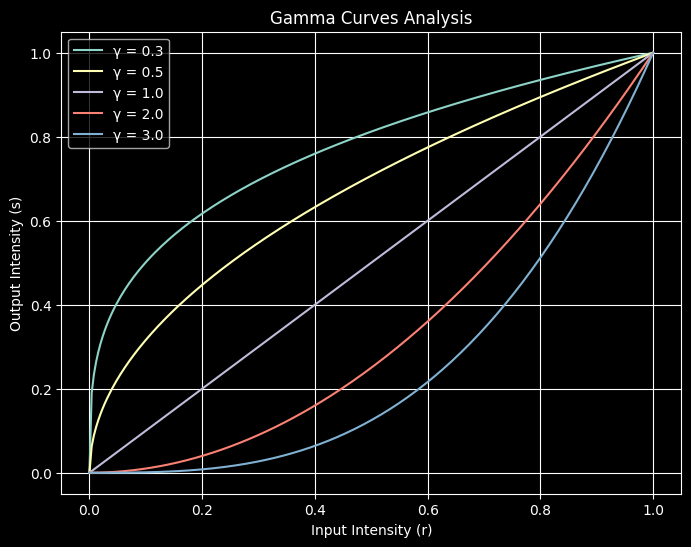

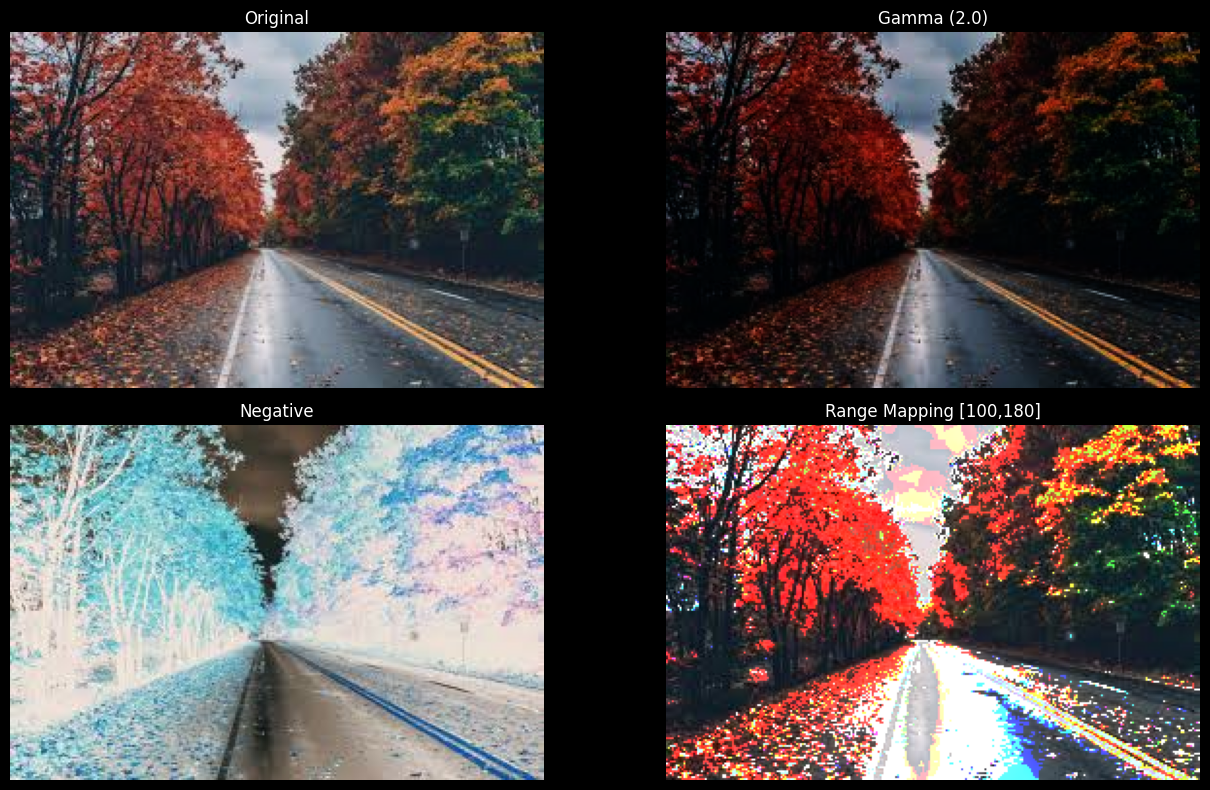

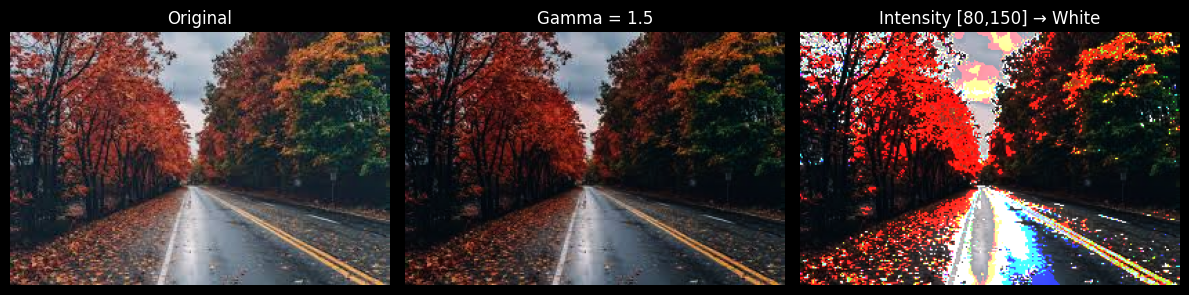

In [24]:
if __name__ == "__main__":
    image_path = "images/test_image_3.jpeg"

    final_execution(image_path)

    enhancement_pipeline(image_path, gamma=1.5, A=80, B=150)